In [ ]:
## Counting words

import pandas as pd
import re
import util
import spacy

In [ ]:
nlp = spacy.load('en_core_web_sm')

def normalizeTokens(word_list, extra_stop=[], lemma = True):
    #We can use a generator here as we just need to iterate over it
    normalized = []
    if type(word_list) == list and len(word_list) == 1:
        word_list = word_list[0]

    if type(word_list) == list:
        word_list = ' '.join([str(elem) for elem in word_list]) 

    doc = nlp(word_list.lower(), disable=['parser', 'ner'])
    
    # add the property of stop word to words considered as stop words
    if len(extra_stop) > 0:
        for stopword in extra_stop:
            lexeme = nlp.vocab[stopword]
            lexeme.is_stop = True

    if lemma:
        for w in doc:
            # if it's not a stop word or punctuation mark, add it to our article
            if w.text != '\n' and not w.is_stop and not w.is_punct and not w.like_num and len(w.text.strip()) > 0:
            # we add the lematized version of the word
                normalized.append(str(w.lemma_))
    else:
        for w in doc:
            # if it's not a stop word or punctuation mark, add it to our article
            if w.text != '\n' and not w.is_stop and not w.is_punct and not w.like_num and len(w.text.strip()) > 0:
            # we add the lematized version of the word
                normalized.append(str(w.text.strip()))

    return normalized

def word_tokenize(word_list):
    tokenized = []
    # pass word list through language model.
    doc = nlp(word_list)
    for token in doc:
        if not token.is_punct and len(token.text.strip()) > 0:
            tokenized.append(token.text)
    return tokenized

def sent_tokenize(word_list, model=nlp):
    doc = model(word_list)
    sentences = [sent.text.strip() for sent in doc.sents]
    return sentences

In [ ]:
## Data
corpus = pd.read_csv('../data/coca_full_text_100k_words.csv')


In [18]:
corpus['source']

0                   ABC_20/20
1                   ABC_20/20
2                   ABC_20/20
3                   ABC_20/20
4                   ABC_20/20
                 ...         
218342    HarvardHealthLetter
218343    HarvardHealthLetter
218344    HarvardHealthLetter
218345    HarvardHealthLetter
218346    HarvardHealthLetter
Name: source, Length: 218236, dtype: object

In [6]:
## Text preprocesing:
## Delete duplicates
before = corpus.shape[0]
corpus = corpus.drop_duplicates(subset=['text'])
after = corpus.shape[0]
print(f'Deleted {before - after} duplicates')

Deleted 111 duplicates


In [7]:
# Argentina
kirchner = corpus[corpus["text"].str.contains("Kirchner")]
macri = corpus[corpus["text"].str.contains("Macri")]
# Bolivia (Morales won in 05,09,14)
morales = corpus[corpus["text"].str.contains("Evo") & corpus["text"].str.contains("president")]
# Chile
bachelet = corpus[corpus["text"].str.contains("Bachelet")]
pinera = corpus[corpus["text"].str.contains("Pinera")]
# Colombia
santos = corpus[(corpus["text"].str.contains("Santos")) & (corpus["text"].str.contains("president"))]
uribe = corpus[(corpus["text"].str.contains("Uribe"))]
# Costa R
solis = corpus[(corpus["text"].str.contains("Solis"))]
chinchilla = corpus[(corpus["text"].str.contains("Chinchilla"))]
arias = corpus[(corpus["text"].str.contains("Arias"))]
# Rep Dom
medina = corpus[(corpus["text"].str.contains("Medina"))]
fenandez = corpus[(corpus["text"].str.contains("Fernandez"))]
# Ecuador (Correa won in 06,09,14)
correa = corpus[(corpus["text"].str.contains("Correa")) & (corpus["text"].str.contains("president"))]
# Guatemala
j_morales = corpus[(corpus["text"].str.contains("Morales"))]
perez = corpus[(corpus["text"].str.contains("Perez")) & (corpus["text"].str.contains("president"))]
colom = corpus[(corpus["text"].str.contains("Colom")) & corpus["text"].str.contains("president")]
# Honduras
hernandez = corpus[(corpus["text"].str.contains("Hernandez"))]
lobo = corpus[(corpus["text"].str.contains("Lobo"))]
zelaya = corpus[(corpus["text"].str.contains("Zelaya"))]
# Mexico
pena_nieto = corpus[(corpus["text"].str.contains("Pena")) & (corpus["text"].str.contains("president"))& (corpus["text"].str.contains("Nieto"))]
calderon = corpus[(corpus["text"].str.contains("Calderón"))]
# Nicaragua (Ortega won in 06,11)
ortega = corpus[corpus["text"].str.contains("Ortega")]
# Panama
varela = corpus[corpus["text"].str.contains("Varela")]
martinelli = corpus[corpus["text"].str.contains("Martinelli")]
# Perú
ollanta = corpus[corpus["text"].str.contains("Ollanta")]
alan = corpus[corpus["text"].str.contains("Alan") & corpus["text"].str.contains("president")]
# Paraguay
cartes = corpus[corpus["text"].str.contains("Cartes")]
lugo = corpus[corpus["text"].str.contains("Lugo")]
# El Salvador
sanchez = corpus[corpus["text"].str.contains("Sanchez")]
funes = corpus[corpus["text"].str.contains("Funes")]
# Uruguay
tabare = corpus[corpus["text"].str.contains("Tabare")]
mujica = corpus[corpus["text"].str.contains("Mujica")]
# Venezuela
maduro = corpus[corpus["text"].str.contains("Maduro")]
chavez = corpus[corpus["text"].str.contains("Chavez")]
print('data frames for each president created')

data frames for each president created


In [8]:
list_df = [kirchner, macri,
            morales, 
            bachelet, pinera, 
            santos, uribe, 
            solis, chinchilla, arias,  
            medina, fenandez, 
            correa, 
            j_morales, perez, colom, 
            hernandez, lobo, zelaya, 
            pena_nieto, calderon, 
            ortega, 
            varela, martinelli, 
            ollanta, alan, 
            cartes, lugo, 
            sanchez, funes, 
            tabare, mujica, 
            maduro, chavez]
list_names = ['kirchner', 'macri',
            'morales', 
            'bachelet', 'pinera', 
            'santos', 'uribe', 
            'solis', 'chinchilla', 'arias', 
            'medina', 'fenandez', 
            'correa', 
            'j_morales', 'perez', 'colom', 
            'hernandez', 'lobo', 'zelaya', 
            'pena_nieto', 'calderon', 
            'ortega', 
            'varela', 'martinelli', 
            'ollanta', 'alan',  
            'cartes', 'lugo', 
            'sanchez', 'funes', 
            'tabare', 'mujica', 
            'maduro', 'chavez']

i = 0
for df in list_df:
    df.name = list_names[i]
    i += 1

In [9]:
for df in list_df:
    print(df.name, df.shape)

kirchner (143, 9)
macri (43, 9)
morales (394, 9)
bachelet (26, 9)
pinera (19, 9)
santos (160, 9)
uribe (161, 9)
solis (194, 9)
chinchilla (12, 9)
arias (232, 9)
medina (608, 9)
fenandez (784, 9)
correa (54, 9)
j_morales (645, 9)
perez (414, 9)
colom (955, 9)
hernandez (1161, 9)
lobo (348, 9)
zelaya (33, 9)
pena_nieto (6, 9)
calderon (0, 9)
ortega (361, 9)
varela (75, 9)
martinelli (35, 9)
ollanta (16, 9)
alan (3008, 9)
cartes (185, 9)
lugo (158, 9)
sanchez (1374, 9)
funes (19, 9)
tabare (10, 9)
mujica (50, 9)
maduro (33, 9)
chavez (969, 9)


Determine the words cutoff point

In [10]:
words_lst = []
words_dict = {}
for df in list_df:
    #sum text strings
    full_text = ' '.join(df['text'])
    words = len(re.findall(r'\b\w+\b', full_text))
    words_lst.append(words)
    words_dict[df.name] = words

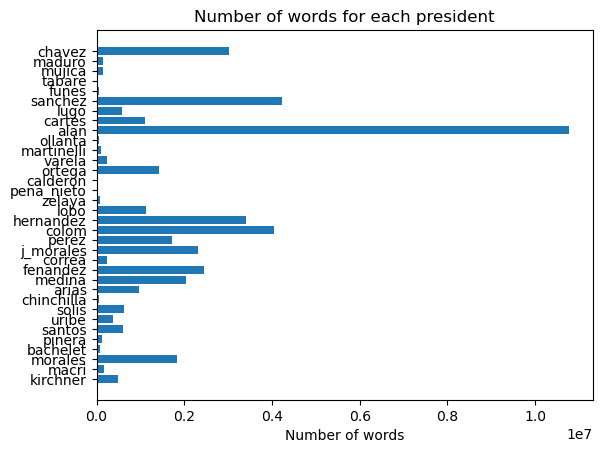

In [11]:
#plot words_lst
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots()
ax.barh(list_names, words_lst)
ax.set_xlabel('Number of words')
ax.set_title('Number of words for each president')
plt.show()

In [ ]:
plt.boxplot(words_lst)
plt.xticks([1], ['Words'])
plt.title('Words per president')
plt.show()

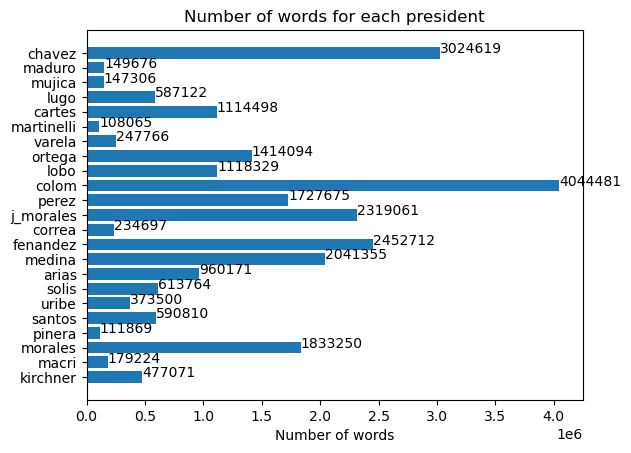

In [12]:
list_df_no_outliers = []
for df in list_df:
    if df.shape[0] < 1000 and words_dict[df.name] > 100000: #filter out outliers
        list_df_no_outliers.append(df)

list_names_no_outliers = [df.name for df in list_df_no_outliers]

words_lst_no_outliers = []
for df in list_df_no_outliers:
    #sum text strings
    full_text = ' '.join(df['text'])
    words = len(re.findall(r'\b\w+\b', full_text))
    words_lst_no_outliers.append(words)

#plot words_lst

fig, ax = plt.subplots()
ax.barh(list_names_no_outliers, words_lst_no_outliers)
ax.set_xlabel('Number of words')
ax.set_title('Number of words for each president')
#add value labels
for i in range(len(words_lst_no_outliers)):
    plt.text(words_lst_no_outliers[i], i, words_lst_no_outliers[i])
plt.show()

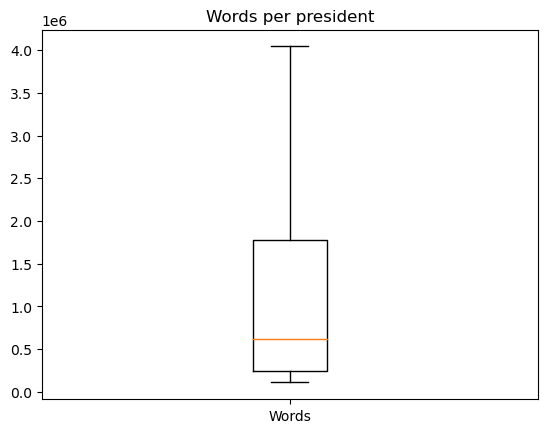

In [13]:
plt.boxplot(words_lst_no_outliers)
plt.xticks([1], ['Words'])
plt.title('Words per president')
plt.show()

In [ ]:
for i, df in enumerate(list_df_no_outliers):
    print(f'working on {df.name}. df {i+1} of {len(list_df_no_outliers)}')
    df['text2'] = df['text'].apply(lambda x: re.sub('[¡!@#$:).;,¿?&><]', '', x.lower()))
    df['tokenized_text'] = df['text2'].apply(lambda x: word_tokenize(x))
    df['normalized_text'] = df['tokenized_text'].apply(lambda x: normalizeTokens(x))

In [15]:
list_count_words = []
for df in list_df_no_outliers:
    countsDict = {}
    for word in df['normalized_text'].sum():
        if word in countsDict:
            countsDict[word] += 1
        else:
            countsDict[word] = 1
    word_counts = sorted(countsDict.items(), key = lambda x : x[1], reverse = True)
    print(df.name, countsDict['president'],word_counts[:10])
    for tpl in word_counts:
        t = (df.name, tpl[0], tpl[1])
        list_count_words.append(t)

kirchner 489 [('<', 4227), ('>', 4202), ('p', 3616), ('year', 1039), ('say', 1010), ('work', 917), ('time', 870), ('student', 782), ('/p', 739), ('new', 732)]
macri 114 [('p', 765), ('<', 749), ('>', 746), ('say', 413), ('right', 338), ('new', 324), ('time', 317), ('year', 311), ('group', 291), ('gay', 278)]
morales 1934 [('<', 13617), ('>', 13608), ('p', 12556), ('new', 4184), ('year', 3423), ('say', 3419), ('state', 3085), ('people', 2743), ('time', 2619), ('work', 2618)]
pinera 186 [('p', 430), ('<', 429), ('>', 429), ('know', 294), ('go', 282), ('say', 268), ('come', 265), ('miner', 252), ('day', 245), ('time', 222)]
santos 948 [('<', 8204), ('>', 8204), ('p', 8188), ('say', 1873), ('new', 1499), ('year', 1488), ('people', 1148), ('president', 948), ('time', 917), ('like', 898)]
uribe 393 [('p', 5078), ('>', 4984), ('<', 4946), ('say', 1224), ('year', 1055), ('r', 744), ('run', 723), ('game', 657), ('uribe', 614), ('sox', 571)]
solis 556 [('p', 7425), ('<', 7331), ('>', 7330), ('st

In [20]:
for df in list_df_no_outliers:
    print(df.name, 'df, number of websites under 3,000 words:', df.shape[0])

kirchner df, number of websites under 3,000 words: 143
macri df, number of websites under 3,000 words: 43
morales df, number of websites under 3,000 words: 394
pinera df, number of websites under 3,000 words: 19
santos df, number of websites under 3,000 words: 160
uribe df, number of websites under 3,000 words: 161
solis df, number of websites under 3,000 words: 194
arias df, number of websites under 3,000 words: 232
medina df, number of websites under 3,000 words: 608
fenandez df, number of websites under 3,000 words: 784
correa df, number of websites under 3,000 words: 54
j_morales df, number of websites under 3,000 words: 645
perez df, number of websites under 3,000 words: 414
colom df, number of websites under 3,000 words: 955
lobo df, number of websites under 3,000 words: 348
ortega df, number of websites under 3,000 words: 361
varela df, number of websites under 3,000 words: 75
martinelli df, number of websites under 3,000 words: 35
cartes df, number of websites under 3,000 words

In [ ]:
pd.set_option('display.max_columns', None)
santos[['text2', 'normalized_text']].head(8)

In [ ]:

# df_word_counts = pd.DataFrame(list_count_words, columns = ['Name', 'Word', 'Count'])

# df_word_counts.to_csv('results/1.word_counts.csv', index=False)

In [22]:
pwd

'c:\\Users\\asarr\\Documents\\Projects\\pol-cul-maps-latam\\notebooks'

In [23]:
for df in list_df_no_outliers:
    filename = '../president_csvs/coca/' + df.name + '.csv'
    df.to_csv(filename)